# Phân loại người sống sót trên tàu Titanic


![Titanic](header.png "Titanic")


## 1. Định nghĩa vấn đề
+ **Mô tả**:
    + train.csv chứa các đặc điểm của hành khách (như Age, Sex, Pclass) và một cột kết quả là Survived (0 = Không, 1 = Có)  
    + test.csv chứa các đặc điểm tương tự nhưng không có cột Survived., 
+ **Dữ liệu vào**:
    + pclass: hạng vé (1 = hạng nhất, 2 = hạng nhì, 3 = hạng ba)
    + Name: Tên của hành khác	
    + sex: giới tính (male: nam, female: nữ)
    + Age: tuổi, tính theo năm
    + sibsp: Số anh/chị/em ruột hoặc vợ/chồng đi cùng trên tàu
    + parch: Số cha/mẹ hoặc con cái đi cùng trên tàu
    + ticket: số vé
    + fare: Giá vé mà hành khách đã trả (đơn vị bảng Anh)
    + cabin: Mã phòng hoặc khoang tàu
    + embarked: Cảng nơi hành khách lên tàu("c": Cherbourg (Pháp), "Q": Queenstown (Ireland), "S": Southampton (Anh))
+ **Kết quả**:  **survival** cho biết người đó còn sống hay không (0 = Không, 1 = Có)


## 2. Chuẩn bị vấn đề (Prepare Problem)

### Khai báo thư viện (Load Libraries)

In [19]:
# Load libraries
import os, sys, re
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

### Tham số chương trình

In [20]:
# params
seed = 42  # random seed để tái dựng lại thực nghiệm giống nhau

exps_dir = "./exps"
if os.path.exists(exps_dir) == False: # tạo thư mục (nếu chưa có)
  os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/feature1"
os.makedirs(save_dir, exist_ok=True)

print(os.path.abspath(save_dir))


d:\Documents\ai_pratice_prj\Titanic\exps\feature1


### Nạp dữ liệu (Load Dataset)

In [21]:

train_df = pd.read_csv("train.csv", index_col="PassengerId")
test_df = pd.read_csv("test.csv", index_col="PassengerId")
display.display(train_df.head())
display.display(train_df.tail())

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Chia dữ liệu thực nghiệm

+ Dữ liệu ban đầu: chia 30% dữ liệu dùng để Test, 70% dùng để train. Tuy nhiên do chúng ta đã cớ tập dữ liệu test nên không cần phải chia
+ Dữ liệu train: chia chiến lược K-Fold với k = 5

## 3. Tạo đặc trưng mới (Feature Engineering)

### (1) Tạo FamilySize = số người thân + 1 (bản thân): giúp phản ánh khả năng sinh tồn trong nhóm gia đình

,Family_cate
PassengerId,
1,Small
2,Small
3,Alone
4,Small
5,Alone
6,Alone
7,Alone
8,Medium
9,Small


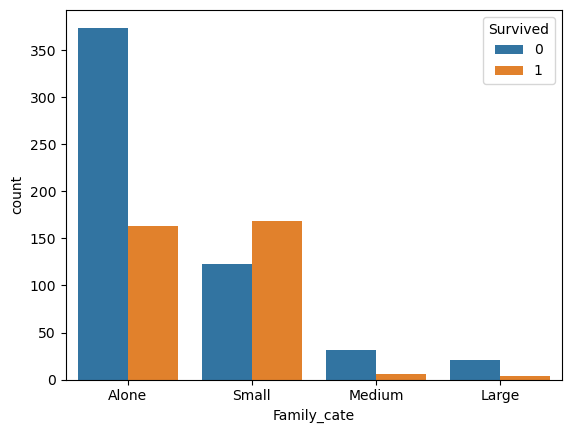

In [22]:
train_df['FamilySize'] = train_df['SibSp'].astype(int) + train_df['Parch'].astype(int) + 1

# Tạo IsAlone = 1 nếu đi một mình, 0 nếu đi cùng: thể hiện hành khách đi một mình – nhóm này thường có khả năng sống sót thấp hơn
train_df["Family_cate"]=pd.cut(train_df['FamilySize'], bins=[0,1,4,6,20], labels=["Alone","Small","Medium","Large"])
display.display(train_df[['Family_cate']].head(10))
sns.countplot(data=train_df, x='Family_cate', hue='Survived')

# Tương tự cho tập test
test_df['FamilySize'] = test_df['SibSp'].astype(int) + test_df['Parch'].astype(int) + 1
test_df["Family_cate"]=pd.cut(test_df['FamilySize'], bins=[0,1,4,6,20], labels=["Alone","Small","Medium","Large"])

**Nhận xét**:
- Đối với những người đi một mình thì khả năng sống sót rất ít, có thể là do khi xảy ra tai nạn không được ai để ý tới.
- Đối với các gia đình nhỏ(2- 4 thành viên) tỷ lệ sống sót khá cao. Trong quá trình tai nạn xảy ra sẽ dễ dàng kiểm soát số lượng thành viên và hỗ trợ nhau tốt hon.
- Cuối cùng với các gia đình vừa và lớn(5-20 thành viên) khả năng sống sót rất ít vì trong lúc ấy các thành viên sẽ không thể nào hỗ trợ được hất tất cả mọi người còn lại.

### (2) Tạo cột Titles(danh xưng)

In [23]:
def extract_title(name):
    p= re.compile(r",([\w\s]+)\.")
    return p.search(name).group(1).strip()
train_df['Title'] = train_df['Name'].apply(extract_title)
display.display(train_df.head())
display.display(train_df['Title'].value_counts())

test_df['Title'] = test_df['Name'].apply(extract_title)
display.display(test_df['Title'].value_counts())



,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Small,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Small,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Small,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Alone,Mr


Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

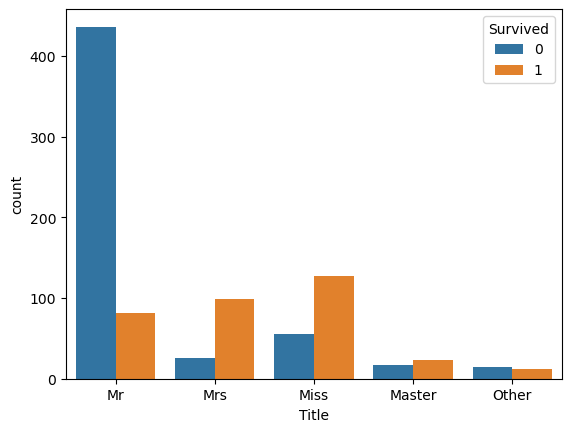

In [24]:
train_df['Title'] = train_df['Title'].apply(lambda x: x if x in ['Mr', 'Miss', 'Mrs', 'Master'] else 'Other')
sns.countplot(data=train_df, x='Title', hue='Survived')

test_df['Title'] = test_df['Title'].apply(lambda x: x if x in ['Mr', 'Miss', 'Mrs', 'Master'] else 'Other')

**Nhận xét**:
- Mr (đàn ông trưởng thành): Chiếm số lượng lớn nhất (hơn 400 người). Tuy nhiên tỷ lệ sống sót rất thấp — cột xanh (chết) cao hơn nhiều so với cam. Vì vậy Nam giới trưởng thành là nhóm tử vong nhiều nhất.
- Mrs (phụ nữ có chồng) và Miss(phụ nữ trẻ): Số lượng ít hơn Mr nhiều, nhưng đa số sống sót (cột cam > xanh). Trong tình huống ấy phụ nữ luôn được ưu tiên cứu (“women and children first”).
- Master (bé trai): Nhóm nhỏ, nhưng đa phần sống sót (cam > xanh). Không ngoài dự đoán trẻ em được ưu tiên cứu trước tất cả.
- Other (tước danh xưng hiếm — như Dr, Rev, Col, Major, v.v.): Số lượng ít, và tỷ lệ tử vong cao hơn sống sót. Có thể phần lớn là nam giới trung niên, nên cũng bị ảnh hưởng giống nhóm Mr.

## 4. Tiền xử lý dữ liệu (Data Preprocessing)

### Làm sạch dữ liệu (Data Cleaning)

#### Xóa dữ liệu trùng nhau

In [25]:
display.display(train_df[train_df.duplicated(keep = False)])

display.display(test_df[test_df.duplicated(keep = False)])

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,,,,


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,,,


**Nhận xét**: Bộ dữ liệu không có bất kỳ dòng nào bị trùng với nhau

#### Xử lý giá trị rỗng, không hợp lệ

##### Kiểm tra dữ liệu bị thiếu

In [26]:
print("="*5, "Null Value", "="*5)
display.display(train_df.isnull().sum())

print("="*5, "Checking NaN", "="*5)
display.display(train_df.isna().sum())



===== Null Value =====


Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
Family_cate      0
Title            0
dtype: int64

===== Checking NaN =====


Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
Family_cate      0
Title            0
dtype: int64

**Nhận xét**:
- Dữ liệu tương đối đầy đủ, chỉ có 3 cột chứa giá trị thiếu:
  - `Age`: 177 giá trị thiếu (~20%)  
  - `Cabin`: 687 giá trị thiếu (~77%)  
  - `Embarked`: 2 giá trị thiếu (<1%)
- Các cột còn lại đầy đủ 100% dữ liệu.


##### Xử lý giá trị bị thiếu
- `Age`: thay các giá trị bị thiếu bằng trung bình giá trị trung bình của toàn bộ cột.
- `Embarked`: Các dòng bị thiếu sẽ nhận giá trị có tần số sao nhất.
- `Cabin`: vì nó có quá nhiều giá trị bị thiếu nên tránh làm ảnh hưởng tới quá trình huấn luyện sau này nên ta sẽ bỏ toàn bộ dòng bị thiếu

In [27]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
train_df.drop(columns=['Cabin'], inplace=True, errors='ignore')

test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df.drop(columns=['Cabin'], inplace=True, errors='ignore')

In [28]:
train_df.dropna(inplace=True)
print("="*5, "Null Value", "="*5)
display.display(train_df.isnull().sum())

print("="*5, "Checking NaN", "="*5)
display.display(train_df.isna().sum())

===== Null Value =====


Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
Family_cate    0
Title          0
dtype: int64

===== Checking NaN =====


Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
Family_cate    0
Title          0
dtype: int64

### Loại bỏ các cột không cần thiết
Ở đây chúng ta đã tạo thêm 2 biến để đếm số lượng thành viên đi chung và danh xưng của từng hành khách. Vì thế chúng ta cớ thể loại bỏ 2 cột object là **Name** và **Ticket** để phù hợp hơn cho mô hình.


In [29]:
train_df.drop(columns=['Name', 'Ticket'], inplace=True, errors='ignore')

test_df.drop(columns=['Name', 'Ticket'], inplace=True, errors='ignore')

display.display(train_df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,2,Small,Mr
2,1,1,female,38.0,1,0,71.2833,C,2,Small,Mrs
3,1,3,female,26.0,0,0,7.9250,S,1,Alone,Miss
4,1,1,female,35.0,1,0,53.1000,S,2,Small,Mrs
5,0,3,male,35.0,0,0,8.0500,S,1,Alone,Mr


### Biến đổi dữ liệu (Data Transforms)

#### Chuyển đổi dữ liệu danh mục (Category) thành dữ liệu số

In [30]:
def Colum_encoder(df, Column_name):
    encoder = LabelEncoder()
    df[Column_name] = encoder.fit_transform(df[Column_name])
    encoder_name = encoder.classes_
    return encoder, encoder_name

for i in ["Sex", "Embarked", "Title", "Family_cate"]:
    train_df[i] = train_df[i].astype(str)
    encoder, names = Colum_encoder(train_df, i)
    print(f"Unique values in {i} after encoding: {names}")
    # Save encoders
    joblib.dump(encoder, f'{save_dir}/{i}_encoder.joblib')
    # Load and check again
    loaded_encoder = joblib.load(f'{save_dir}/{i}_encoder.joblib')
    print(f"Loaded {i} Encoder Classes:")
    print(loaded_encoder.classes_)






Unique values in Sex after encoding: ['female' 'male']
Loaded Sex Encoder Classes:
['female' 'male']
Unique values in Embarked after encoding: ['C' 'Q' 'S']
Loaded Embarked Encoder Classes:
['C' 'Q' 'S']
Unique values in Title after encoding: ['Master' 'Miss' 'Mr' 'Mrs' 'Other']
Loaded Title Encoder Classes:
['Master' 'Miss' 'Mr' 'Mrs' 'Other']
Unique values in Family_cate after encoding: ['Alone' 'Large' 'Medium' 'Small']
Loaded Family_cate Encoder Classes:
['Alone' 'Large' 'Medium' 'Small']


Tương tự cho tập test

In [31]:
for i in ["Sex", "Embarked", "Title", "Family_cate"]:
    test_df[i] = test_df[i].astype(str)
    encoder, names = Colum_encoder(test_df, i)
    print(f"Unique values in {i} after encoding: {names}")
    # Save encoders
    joblib.dump(encoder, f'{save_dir}/{i}_encoder.joblib')
    # Load and check again
    loaded_encoder = joblib.load(f'{save_dir}/{i}_encoder.joblib')
    print(f"Loaded {i} Encoder Classes:")
    print(loaded_encoder.classes_)

Unique values in Sex after encoding: ['female' 'male']
Loaded Sex Encoder Classes:
['female' 'male']
Unique values in Embarked after encoding: ['C' 'Q' 'S']
Loaded Embarked Encoder Classes:
['C' 'Q' 'S']
Unique values in Title after encoding: ['Master' 'Miss' 'Mr' 'Mrs' 'Other']
Loaded Title Encoder Classes:
['Master' 'Miss' 'Mr' 'Mrs' 'Other']
Unique values in Family_cate after encoding: ['Alone' 'Large' 'Medium' 'Small']
Loaded Family_cate Encoder Classes:
['Alone' 'Large' 'Medium' 'Small']


In [32]:
display.display(train_df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,
1,0,3,1,22.0,1,0,7.2500,2,2,3,2
2,1,1,0,38.0,1,0,71.2833,0,2,3,3
3,1,3,0,26.0,0,0,7.9250,2,1,0,1
4,1,1,0,35.0,1,0,53.1000,2,2,3,3
5,0,3,1,35.0,0,0,8.0500,2,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,1,27.0,0,0,13.0000,2,1,0,4
888,1,1,0,19.0,0,0,30.0000,2,1,0,1
889,0,3,0,28.0,1,2,23.4500,2,4,3,1


#### Chuyển đổi dữ liệu danh mục (Category) thành dạng OneHot

Một số thuật toán khi chuyển đổi cột dạng danh mục thành kiểu OneHot thì cho hiệu suất cao hơn.

Bên cạnh đó, khi huấn luyện mô hình với dạng hàm mất mát CategoryEntropy thì cũng cần chuyển thuộc tính phân lớp sang dạng OneHot.

In [33]:
def One_Hot_Encoding(df, column_name):
    # Thực hiện One-Hot Encoding
    dummies = pd.get_dummies(df[column_name], prefix=column_name)
    dummies = dummies.astype(int)
    df= pd.DataFrame(dummies.values, columns=dummies.columns)
    return df
df_onehot_S= One_Hot_Encoding(train_df,"Sex")
display.display(df_onehot_S)

,Sex_0,Sex_1
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
886,0,1
887,1,0
888,1,0
889,0,1


In [34]:
df_onehot_E= One_Hot_Encoding(train_df,"Embarked")
display.display(df_onehot_E)

,Embarked_0,Embarked_1,Embarked_2
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,0,0,1
889,1,0,0


#### Chuẩn hóa dữ liệu (Data Normalize)

Chuẩn hóa các tính chất để đưa về cùng một miền trị
+ Min-Max Normalization
$$
z = \frac{x - min(x)}{max(x) - min(x)}
$$
+ Standard Normalization
$$
z = \frac{x - \mu}{\sigma}
$$

**Lưu ý**: Quá trình chuẩn hóa có thể làm trong phần thực nghiệm thuật toán

##### Min-Max Normalization

In [35]:
train_df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'FamilySize', 'Family_cate', 'Title'],
      dtype='object')

Chúng ta sẽ chọn ra những biến phù hợp để chuẩn hóa nó đưa về cùng 1 miền giá trị

- Age (Tuổi) $0.42 - 80$ Phạm vi rộng, cần đưa về $[0, 1]$.
- Fare (Giá vé)$0 - 512$Phạm vi rất rộng, có thể bị lệch (skewed).
- Parch (Số cha mẹ/con cái)$0 - 6$Cần chuẩn hóa cùng với các biến khác.
- SibSp (Số anh chị em/vợ chồng)$0 - 8$Cần chuẩn hóa cùng với các biến kh

In [36]:
# Min-Max Normalization
scale_columns = ["Age", "Fare", "Parch","SibSp","FamilySize"]
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(train_df[scale_columns])
df_minmax = train_df.copy()
df_minmax[scale_columns] = minmax_scaler.transform(train_df[scale_columns])
display.display(df_minmax)

# Tương tự cho tập test
scale_columns = ["Age", "Fare", "Parch","SibSp","FamilySize"]
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(test_df[scale_columns])
df_minmax_test = test_df.copy()
df_minmax_test[scale_columns] = minmax_scaler.transform(test_df[scale_columns])

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,
1,0,3,1,0.271174,0.125,0.000000,0.014151,2,0.1,3,2
2,1,1,0,0.472229,0.125,0.000000,0.139136,0,0.1,3,3
3,1,3,0,0.321438,0.000,0.000000,0.015469,2,0.0,0,1
4,1,1,0,0.434531,0.125,0.000000,0.103644,2,0.1,3,3
5,0,3,1,0.434531,0.000,0.000000,0.015713,2,0.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,1,0.334004,0.000,0.000000,0.025374,2,0.0,0,4
888,1,1,0,0.233476,0.000,0.000000,0.058556,2,0.0,0,1
889,0,3,0,0.346569,0.125,0.333333,0.045771,2,0.3,3,1


In [37]:
minmax_scaler.__dict__

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Age', 'Fare', 'Parch', 'SibSp', 'FamilySize'], dtype=object),
 'n_features_in_': 5,
 'n_samples_seen_': 418,
 'scale_': array([0.01318739, 0.00195187, 0.11111111, 0.125     , 0.1       ]),
 'min_': array([-0.00224186,  0.        ,  0.        ,  0.        , -0.1       ]),
 'data_min_': array([0.17, 0.  , 0.  , 0.  , 1.  ]),
 'data_max_': array([ 76.    , 512.3292,   9.    ,   8.    ,  11.    ]),
 'data_range_': array([ 75.83  , 512.3292,   9.    ,   8.    ,  10.    ])}

In [38]:
# Save encoders
joblib.dump(minmax_scaler, f'{save_dir}/minmax_scaler.joblib')

['./exps/feature1/minmax_scaler.joblib']

In [39]:
joblib.load(f'{save_dir}/minmax_scaler.joblib').__dict__

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Age', 'Fare', 'Parch', 'SibSp', 'FamilySize'], dtype=object),
 'n_features_in_': 5,
 'n_samples_seen_': 418,
 'scale_': array([0.01318739, 0.00195187, 0.11111111, 0.125     , 0.1       ]),
 'min_': array([-0.00224186,  0.        ,  0.        ,  0.        , -0.1       ]),
 'data_min_': array([0.17, 0.  , 0.  , 0.  , 1.  ]),
 'data_max_': array([ 76.    , 512.3292,   9.    ,   8.    ,  11.    ]),
 'data_range_': array([ 75.83  , 512.3292,   9.    ,   8.    ,  10.    ])}

In [40]:
# save scale_columns
np.savez(f'{save_dir}/scale_columns.npz', scale_columns = scale_columns)
dict(np.load(f'{save_dir}/scale_columns.npz'))

{'scale_columns': array(['Age', 'Fare', 'Parch', 'SibSp', 'FamilySize'], dtype='<U10')}

<Axes: >

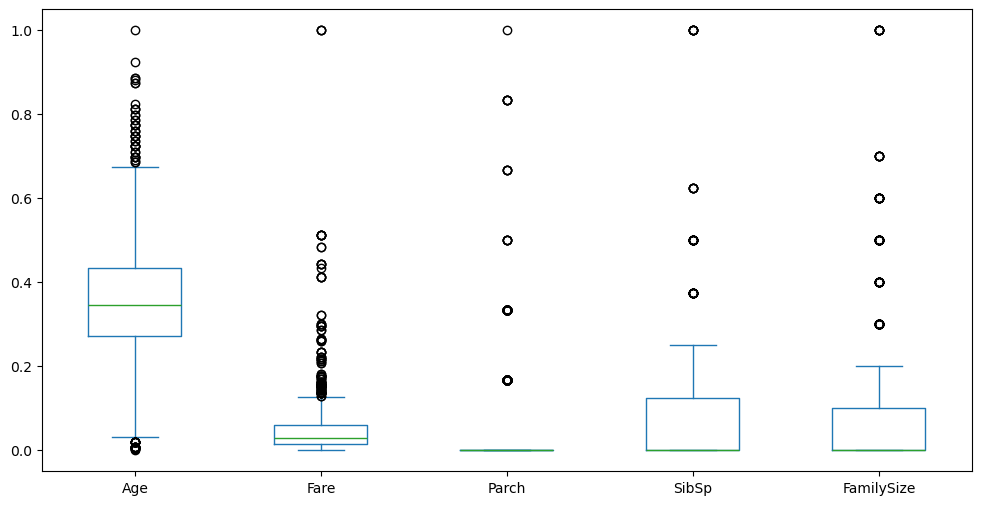

In [41]:
df_minmax[scale_columns].plot(kind="box", figsize=(12,6))

##### Standard Normalization

In [42]:
# Standard Normalization
standard_scaler = StandardScaler()
standard_scaler.fit(train_df[scale_columns])
df_standard = train_df.copy()
df_standard[scale_columns] = standard_scaler.transform(train_df[scale_columns])
display.display(df_standard)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,
1,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,2,0.059160,3,2
2,1,1,0,0.663861,0.432793,-0.473674,0.786845,0,0.059160,3,3
3,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,2,-0.560975,0,1
4,1,1,0,0.433312,0.432793,-0.473674,0.420730,2,0.059160,3,3
5,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,2,-0.560975,0,2
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,1,-0.181487,-0.474545,-0.473674,-0.386671,2,-0.560975,0,4
888,1,1,0,-0.796286,-0.474545,-0.473674,-0.044381,2,-0.560975,0,1
889,0,3,0,-0.104637,0.432793,2.008933,-0.176263,2,1.299429,3,1


<Axes: >

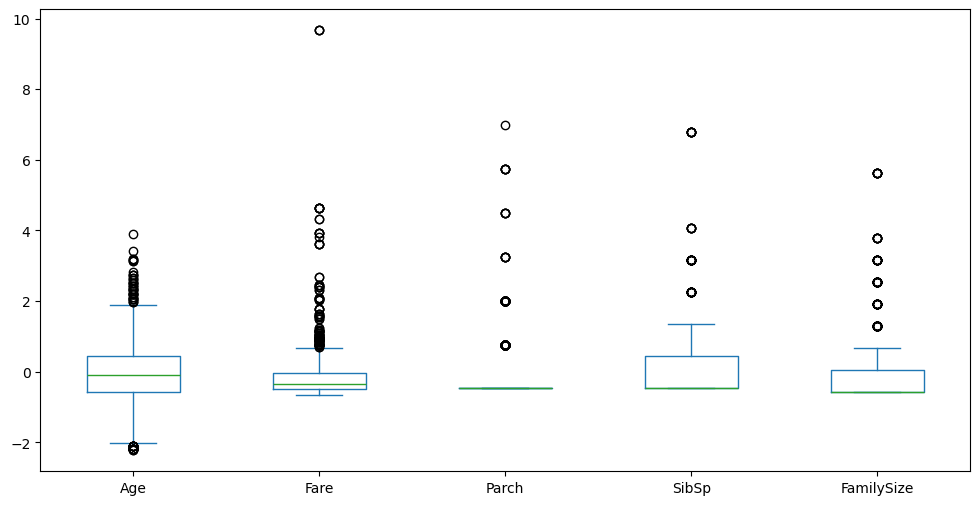

In [43]:
df_standard[scale_columns].plot(kind="box", figsize=(12,6))

In [44]:
standard_scaler.__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Age', 'Fare', 'Parch', 'SibSp', 'FamilySize'], dtype=object),
 'n_features_in_': 5,
 'n_samples_seen_': np.int64(891),
 'mean_': array([29.36158249, 32.20420797,  0.38159371,  0.52300786,  1.90460157]),
 'var_': array([1.69322249e+02, 2.46666531e+03, 6.48999031e-01, 1.21467827e+00,
        2.60032675e+00]),
 'scale_': array([13.01238827, 49.66553444,  0.80560476,  1.10212444,  1.61255287])}

In [45]:
# Save encoders
joblib.dump(standard_scaler, f'{save_dir}/standard_scaler.joblib')

['./exps/feature1/standard_scaler.joblib']

In [46]:
joblib.load(f'{save_dir}/standard_scaler.joblib').__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Age', 'Fare', 'Parch', 'SibSp', 'FamilySize'], dtype=object),
 'n_features_in_': 5,
 'n_samples_seen_': np.int64(891),
 'mean_': array([29.36158249, 32.20420797,  0.38159371,  0.52300786,  1.90460157]),
 'var_': array([1.69322249e+02, 2.46666531e+03, 6.48999031e-01, 1.21467827e+00,
        2.60032675e+00]),
 'scale_': array([13.01238827, 49.66553444,  0.80560476,  1.10212444,  1.61255287])}

### Lưu dữ liệu Features

+ Chuyển đổi dữ liệu sang dạng numpy với phần Input (X_data), Output (y_data)
+ Lưu tất cả thông tin để chuẩn bị chạy thuật toán

In [47]:
# MinMax
x_train = df_minmax.values[:, 1:]   
y_train = df_minmax.values[:, 0]

display.display(df_minmax.head())

print("+ x_train: \n ", x_train[:5, :])
print("+ y_train: \n ", y_train[:5])

np.savez(f'{save_dir}/feat_minmax.npz', x_train = x_train, y_train = y_train)
df_minmax.to_excel(f'{save_dir}/df_minmax.xlsx', index=False)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,
1,0,3,1,0.271174,0.125,0.0,0.014151,2,0.1,3,2
2,1,1,0,0.472229,0.125,0.0,0.139136,0,0.1,3,3
3,1,3,0,0.321438,0.000,0.0,0.015469,2,0.0,0,1
4,1,1,0,0.434531,0.125,0.0,0.103644,2,0.1,3,3
5,0,3,1,0.434531,0.000,0.0,0.015713,2,0.0,0,2


+ x_train: 
  [[3.         1.         0.27117366 0.125      0.         0.01415106
  2.         0.1        3.         2.        ]
 [1.         0.         0.4722292  0.125      0.         0.13913574
  0.         0.1        3.         3.        ]
 [3.         0.         0.32143755 0.         0.         0.01546857
  2.         0.         0.         1.        ]
 [1.         0.         0.43453129 0.125      0.         0.1036443
  2.         0.1        3.         3.        ]
 [3.         1.         0.43453129 0.         0.         0.01571255
  2.         0.         0.         2.        ]]
+ y_train: 
  [0. 1. 1. 1. 0.]


In [48]:

x_train = df_standard.values[:, :-1]
y_train = df_standard.values[:, -1]
display.display(df_standard.head())

print("+ x_train: \n ", x_train[:5, :])
print("+ y_train: \n ", y_train[:5])

np.savez(f'{save_dir}/feat_standard.npz', x_train = x_train, y_train = y_train) #luu dữ liệu đã chuẩn hóa
df_minmax.to_excel(f'{save_dir}/df_standard.xlsx', index=False)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
PassengerId,,,,,,,,,,,
1,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,2,0.059160,3,2
2,1,1,0,0.663861,0.432793,-0.473674,0.786845,0,0.059160,3,3
3,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,2,-0.560975,0,1
4,1,1,0,0.433312,0.432793,-0.473674,0.420730,2,0.059160,3,3
5,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,2,-0.560975,0,2


+ x_train: 
  [[ 0.          3.          1.         -0.56573646  0.43279337 -0.47367361
  -0.50244517  2.          0.05915988  3.        ]
 [ 1.          1.          0.          0.66386103  0.43279337 -0.47367361
   0.78684529  0.          0.05915988  3.        ]
 [ 1.          3.          0.         -0.25833709 -0.4745452  -0.47367361
  -0.48885426  2.         -0.56097483  0.        ]
 [ 1.          1.          0.          0.4333115   0.43279337 -0.47367361
   0.42073024  2.          0.05915988  3.        ]
 [ 0.          3.          1.          0.4333115  -0.4745452  -0.47367361
  -0.48633742  2.         -0.56097483  0.        ]]
+ y_train: 
  [2. 3. 1. 3. 2.]


In [49]:
#Lưu lại tập test đã xư lý
test_df.to_csv(os.path.join(save_dir, "test_preprocessed.csv"))

# Kết thúc

In [50]:

cur_dir = os.getcwd()  # lấy đường dẫn hiện tại
notebook_path = os.path.join(cur_dir, "preprocessing.ipynb")

# Kiểm tra xem file có tồn tại không
if os.path.exists(notebook_path):
    !jupyter nbconvert "{notebook_path}" --to html
else:
    print("Không tìm thấy file preprocessing.ipynb.")

[NbConvertApp] Converting notebook d:\Documents\ai_pratice_prj\Titanic\preprocessing.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 494585 bytes to d:\Documents\ai_pratice_prj\Titanic\preprocessing.html
